In [2]:
#CONFUSION MATRIX DAN METRIK DENGAN SCIKIT-LEARN
#KODE: METRIK EVALUASI DASAR
#LISTING 1: evaluation_metrics.py
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate dataset imbalanced
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluasi
print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("(Format: [[TN, FP], [FN, TP]])")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Class 0', 'Class 1']
))

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretasi:")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

EVALUASI MODEL
Accuracy  : 0.9533
Precision : 0.8696
Recall    : 0.6452
F1-Score  : 0.7407

Confusion Matrix:
[[266   3]
 [ 11  20]]
(Format: [[TN, FP], [FN, TP]])

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97       269
     Class 1       0.87      0.65      0.74        31

    accuracy                           0.95       300
   macro avg       0.91      0.82      0.86       300
weighted avg       0.95      0.95      0.95       300


Interpretasi:
True Negatives  : 266
False Positives : 3
False Negatives : 11
True Positives  : 20


AUC Score : 0.9076


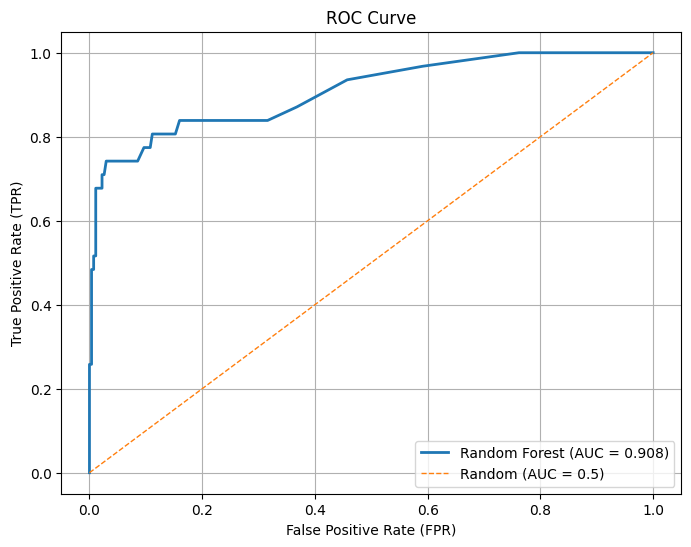


Optimal threshold : 0.3300
TPR              : 0.7419
FPR              : 0.0297


In [4]:
# ROC CURVE DAN AUC
# LISTING 2: roc_curve.py

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

# Generate dataset (imbalanced)
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Probabilitas (bukan label)
y_proba = model.predict_proba(X_test)[:, 1]

# ROC + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

print(f"AUC Score : {auc:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Threshold optimal (Youden’s J)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold : {optimal_threshold:.4f}")
print(f"TPR              : {tpr[optimal_idx]:.4f}")
print(f"FPR              : {fpr[optimal_idx]:.4f}")

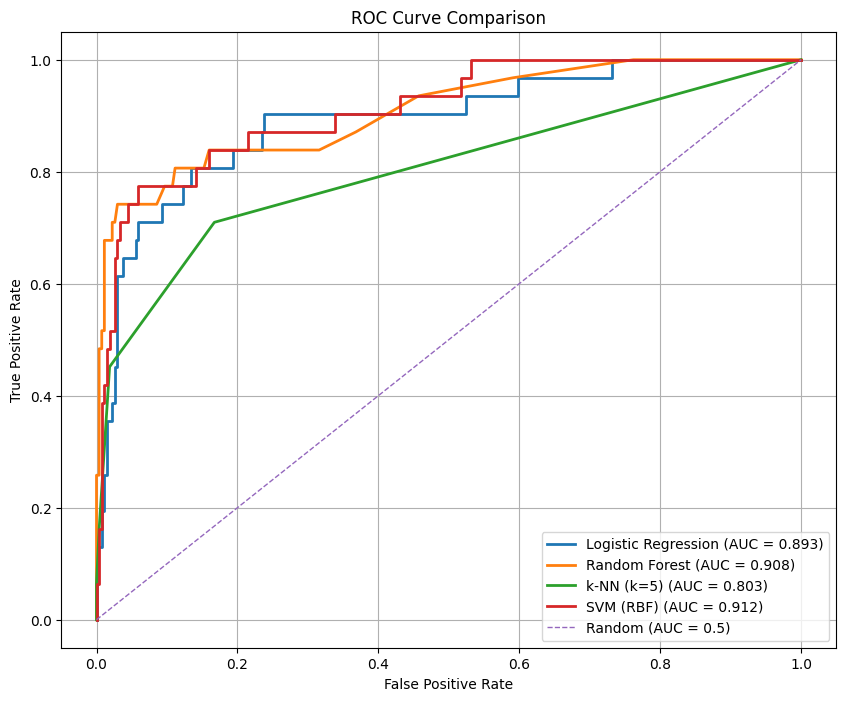

In [6]:
# PERBANDINGAN ROC CURVE BEBERAPA MODEL
# LISTING 3: compare_roc.py

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generate dataset (imbalanced)
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Definisikan model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# Plot ROC
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Garis random
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [8]:
# IMPLEMENTASI K-FOLD CROSS VALIDATION
# LISTING 4: cross_validation.py

from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np

# Generate dataset (imbalanced)
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# ============= HOLD-OUT =============
print("=" * 50)
print("HOLD-OUT VALIDATION")
print("=" * 50)

scores_holdout = []

for i in range(10):  # 10 kali ulangan
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.3,
        random_state=i,
        stratify=y
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr, y_tr)
    scores_holdout.append(model.score(X_te, y_te))

print(f"Mean accuracy : {np.mean(scores_holdout):.4f}")
print(f"Std           : {np.std(scores_holdout):.4f}")

# ============= K-FOLD CV =============
print("\n" + "=" * 50)
print("K-FOLD CROSS VALIDATION")
print("=" * 50)

model = RandomForestClassifier(random_state=42)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"k-Fold (k=5) - Mean : {scores_kfold.mean():.4f} (+/- {scores_kfold.std():.4f})")

# ============= STRATIFIED K-FOLD =============
print("\n" + "=" * 50)
print("STRATIFIED K-FOLD CV")
print("=" * 50)

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')

print(f"Stratified k-Fold - Mean : {scores_strat.mean():.4f} (+/- {scores_strat.std():.4f})")

# ============= PERBANDINGAN NILAI K =============
print("\n" + "=" * 50)
print("PERBANDINGAN BERBAGAI NILAI K")
print("=" * 50)

k_values = [3, 5, 7, 10]

for k in k_values:
    strat_kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')
    print(f"k={k}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

HOLD-OUT VALIDATION
Mean accuracy : 0.9513
Std           : 0.0090

K-FOLD CROSS VALIDATION
k-Fold (k=5) - Mean : 0.9540 (+/- 0.0080)

STRATIFIED K-FOLD CV
Stratified k-Fold - Mean : 0.9530 (+/- 0.0117)

PERBANDINGAN BERBAGAI NILAI K
k=3: Mean = 0.9450, Std = 0.0135
k=5: Mean = 0.9530, Std = 0.0117
k=7: Mean = 0.9530, Std = 0.0148
k=10: Mean = 0.9490, Std = 0.0170


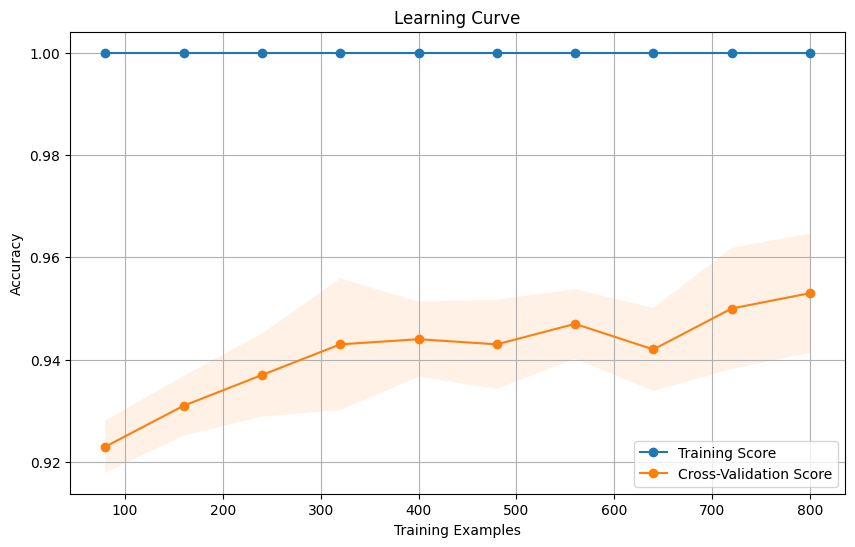


INTERPRETASI:
MODEL GOOD → Training dan validation seimbang


In [10]:
# LEARNING CURVE UNTUK DIAGNOSTIK MODEL
# LISTING 5: learning_curve.py

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

# Generate dataset (imbalanced)
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)

# Hitung learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# Mean & std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.1
)

plt.plot(
    train_sizes,
    train_mean,
    'o-',
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    label='Cross-Validation Score'
)

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid()
plt.show()

# Interpretasi
gap = train_mean[-1] - test_mean[-1]

print("\nINTERPRETASI:")
if gap > 0.1:
    print("MODEL OVERFITTING → Training jauh lebih tinggi dari validation")
elif gap < -0.05:
    print("MODEL UNDERFITTING → Model terlalu sederhana")
else:
    print("MODEL GOOD → Training dan validation seimbang")